# Load packages

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from functions import *
import timeit
import torch
from model import MultiAttModel
import esm

# Load model

In [2]:
# path to model weights
topt_pth = '../model_topt_window.3_r2.0.57.pth';# you can download the weights from release v1.0.0
# define device
device = torch.device('cpu')
# define seq2Topt model
emb_dim= 320; window=3; n_head = 4; n_RD = 4;
model = MultiAttModel( emb_dim, window, n_head, n_RD)
model.to(device);
# load weights into the model
model.load_state_dict(torch.load( topt_pth, map_location=device  ));
model.eval();

/tmp/ipykernel_4032220/2839840922.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load( topt_pth, map_location=device  ));


# Load ESM-2

In [3]:
# We use esm2_t6_8M_UR50D, 6 layers, dimension size = 320.
esm2_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D() # 6 layers
esm2_model = esm2_model.to(device)
esm2_batch_converter = alphabet.get_batch_converter()

# Example

In [4]:
topt_data = pd.read_csv('../data/Topt/sequence_ogt_topt.csv')
example_seq = topt_data['sequence'][0]
print(example_seq)
print(len(example_seq))

MKNKVVVVTGVPGVGGTTLTQKTIEKLKEEGIEYKMVNFGTVMFEVAKEEGLVEDRDQMRKLDPDTQKRIQKLAGRKIAEMAKESNVIVDTHSTVKTPKGYLAGLPIWVLEELNPDIIVIVETSSDEILMRRLGDATRNRDIELTSDIDEHQFMNRCAAMAYGVLTGATVKIIKNRDGLLDKAVEELISVLK
192


In [5]:
def predict(seq):
    # seq: input protein sequence
    inputs = [('Temp', seq)] 
    batch_labels, batch_strs, batch_tokens = esm2_batch_converter(inputs)
    batch_tokens = batch_tokens.to(device=device, non_blocking=True)
    with torch.no_grad():
        emb = esm2_model(batch_tokens, repr_layers=[6], return_contacts=False)
    emb = emb["representations"][6]
    emb = emb.transpose(1,2)
    emb = emb.to(device)
    with torch.no_grad():
        preds = model( emb )
    return preds

In [6]:
# The prediction output is Topt/Topt_max.
Topt_max=120
print(predict(example_seq)*Topt_max)

tensor([[57.3690]])


# Runtime of different sequence lengths

In [7]:
factors = np.arange(1,16)
runtimes = []
for factor in factors:
    start = timeit.default_timer()
    pred = predict(example_seq*factor)
    stop = timeit.default_timer()
    runtimes.append(stop-start)

(0.0, 5.0)

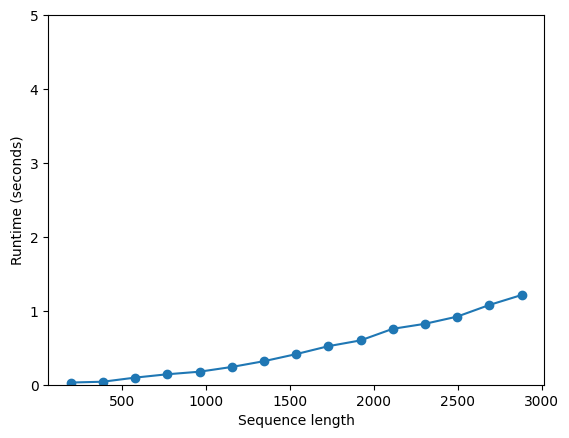

In [8]:
plt.plot( [len(example_seq)*f for f in factors], runtimes, marker='o')
plt.xlabel('Sequence length')
plt.ylabel('Runtime (seconds)')
plt.ylim([0,5])